# ADAML - NASA Turbofan A

**Team members:** Radomir Babek, Vojtech Vondracek, Jakub Rysanek

**Goal:** creation of KPLS models using 4 train/test datasets, predicting remaining useful life

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["PYTHONWARNINGS"] = (
    "ignore:y residual is constant at iteration:UserWarning:sklearn.cross_decomposition._pls"
)

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"y residual is constant at iteration \d+",
    category=UserWarning,
    module=r"sklearn\.cross_decomposition\._pls"
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics.pairwise import rbf_kernel, laplacian_kernel, chi2_kernel
from sklearn.preprocessing import KernelCenterer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from optimizer import optimize
from kernel import cauchy_kernel, polynomial_kernel


ImportError: cannot import name 'polynomial_kernel' from 'kernel' (/Users/arbee/Documents/LUT/AdvancedMachineLearning/TurbofanEngine/kernel.py)

## Data loading

In [ ]:
def filter_no_variance(data):
    # Select only sensor columns
    sensor_cols = [col for col in data.columns if "sensor measurement" in col]

    # # Keep only sensors with non-zero variance and with their orig index
    valid_cols = []
    filtered_cols = []
    for i, col in enumerate(sensor_cols):
        if data[col].var() > 1e-8:
            valid_cols.append((i, col))
        else:
            filtered_cols.append(col)

    print("Zero variance columns (constant values):", filtered_cols)

    data = data.drop(columns=filtered_cols)
    return data, filtered_cols

def add_mean_max_min_column(data, window = 25):
  sensor_cols = [c for c in data.columns if "sensor measurement" in c]
  for i, col in enumerate(sensor_cols):
      # SM1_mean is mean of window values from sensor measurement 1
      data[f"SM{i+1}_mean" ] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).mean()
      )
      data[f"SM{i+1}_max"] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).max()
      )
      data[f"SM{i+1}_min"] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).min()
      )

def from_file(train_file_name):
    names = [
      "unit number",
      "time, in cycles",
      "operational setting 1",
      "operational setting 2",
      "operational setting 3"
        ]

    sen_measurements = [f"sensor measurement {i}" for i in range(1, 22)]
    names = names + sen_measurements
    data = pd.read_csv(train_file_name, sep=r'\s+', names=names)

    return data

def train_from_file(file_name, validation_partition = 0.2):
    data = from_file(file_name)

    data, filtered_cols = filter_no_variance(data)
    add_mean_max_min_column(data)

    #COUNTING RUL
    units = dict(tuple(data.groupby("unit number")))
    new_units = []
    for u_id in units:
        u = units[u_id]
        u = u.drop(columns=[
                        "operational setting 1",
                        "operational setting 2",
                        "operational setting 3"])

        failure_time = u.shape[0] + 1
        u["RUL"] = failure_time - u["time, in cycles"]
        new_units.append(u)

    units = new_units

    # SPLITTING VALIDATION / TRAIN
    validation_unit_count = math.ceil(len(units) * validation_partition)
    np.random.seed(42)
    np.random.shuffle(units)

    validation_units = units[:validation_unit_count]
    train_units = units[validation_unit_count:]

    validation_data = pd.concat(validation_units)
    train_data = pd.concat(train_units)

    return train_data, validation_data, filtered_cols

def test_from_file(file_name, gt_file_name, dropped_cols):
    data = from_file(file_name)
    data = data.drop(columns=dropped_cols)

    add_mean_max_min_column(data)

    #read file, where there is only one number on a line into a vector of these numbers
    gt = np.loadtxt(gt_file_name)

    #COUNTING RUL
    units = dict(tuple(data.groupby("unit number")))
    new_units = []
    i = 0
    for u_id in units:
        u = units[u_id]
        u = u.drop(columns=[
                        "operational setting 1",
                        "operational setting 2",
                        "operational setting 3"])
        RUL = gt[i]
        u["RUL"] = int(RUL + u.shape[0] + 1) - u["time, in cycles"]
        i += 1
        new_units.append(u)

    units = new_units

    test_data = pd.concat(units)
    return test_data

## Data normalization

In [ ]:
def normalizeRUL(Y, y_min, y_max):
    Y_scaled = (Y - y_min) / (y_max - y_min)
    return Y_scaled

def normalize_data(train_data, validation_data, test_data, normRUL=False):
    sensor_cols = [
        c for c in train_data.columns 
        if (("sensor measurement" in c) or ("mean" in c) or ("max" in c) or ("min" in c))
        and c not in ["unit number", "time_in_cycles"]
    ]
    print(sensor_cols)

    mu_train = train_data[sensor_cols].mean(axis=0)
    sd_train = train_data[sensor_cols].std(axis=0, ddof=0)

    sd_r = sd_train.replace(0, 1)  # prevence dělení nulou

    train_data[sensor_cols]      = (train_data[sensor_cols     ] - mu_train) / sd_r
    validation_data[sensor_cols] = (validation_data[sensor_cols] - mu_train) / sd_r
    test_data[sensor_cols]       = (test_data[sensor_cols      ] - mu_train) / sd_r

    #Normalize RUL
    if normRUL==True:
        y_min, y_max = train_data["RUL"].min(), train_data["RUL"].max()
        train_data["RUL"] = normalizeRUL(train_data["RUL"], y_min, y_max)
        validation_data["RUL"] = normalizeRUL(validation_data["RUL"], y_min, y_max)
        test_data["RUL"] = normalizeRUL(test_data["RUL"], y_min, y_max)

    return train_data, validation_data, test_data, mu_train, sd_train

## Subsampling of overly large datasets

In [ ]:
def subsample_time_series(df, target_rows=20000, unit_col="unit number",
                          order_col=None, keep_tail=50, min_per_unit=40, seed=42):
    """
    Model-agnostic thinning:
      - keep last `keep_tail` rows of every unit
      - allocate the remaining budget across units proportionally to their length
      - uniformly sample (by order index) from the early part
    """
    import numpy as np, pandas as pd

    rng = np.random.RandomState(seed)
    groups = {u: g.sort_values(order_col) if order_col else g
              for u, g in df.groupby(unit_col, sort=False)}

    # 1) keep tails
    tails = [g.tail(keep_tail) if len(g) > keep_tail else g for g in groups.values()]
    tail_df = pd.concat(tails, ignore_index=False).drop_duplicates()
    remaining = max(0, target_rows - len(tail_df))

    if remaining <= 0:
        return tail_df.sample(n=target_rows, random_state=seed)

    # 2) heads to sample from
    heads = {u: (g.iloc[:-keep_tail] if len(g) > keep_tail else g.iloc[0:0])
             for u, g in groups.items()}
    head_sizes = {u: len(h) for u, h in heads.items()}
    total_head = sum(head_sizes.values())
    if total_head == 0:
        return tail_df.sample(n=target_rows, random_state=seed)

    # 3) allocate samples per unit proportionally (with a minimum)
    alloc = {u: 0 for u in heads}
    for u, n in head_sizes.items():
        if n > 0:
            alloc[u] = int(round(remaining * (n / total_head)))

    # enforce per-unit min where possible
    # (then trim back to exact target by removing from largest allocations)
    for u, n in head_sizes.items():
        if n > 0:
            alloc[u] = min(n, max(min_per_unit, alloc[u]))
    diff = remaining - sum(alloc.values())
    if diff != 0:
        # adjust by ±1 starting from units with largest heads
        by_need = sorted(head_sizes.items(), key=lambda kv: kv[1], reverse=True)
        i = 0
        while diff != 0 and i < len(by_need):
            u, n = by_need[i]
            cap = (n - alloc[u]) if diff > 0 else alloc[u]
            if cap > 0:
                alloc[u] += 1 if diff > 0 else -1
                diff += -1 if diff > 0 else 1
            else:
                i += 1

    # 4) sample within each head uniformly by index (order-aware, no label peeking)
    picks = []
    for u, h in heads.items():
        k = alloc[u]
        if k <= 0 or len(h) == 0:
            continue
        idx = np.linspace(0, len(h) - 1, num=k, dtype=int)
        picks.append(h.iloc[idx])

    sampled_heads = pd.concat(picks, ignore_index=False) if picks else df.iloc[0:0]
    sub = pd.concat([sampled_heads, tail_df], ignore_index=False).sort_index()
    # if any rounding drift remains, fix it exactly
    if len(sub) > target_rows:
        sub = sub.sample(n=target_rows, random_state=seed)
    return sub


## KPLS

In [ ]:
def fit_model(X,y, n_lv, kernel_f, gamma):
    K_train = kernel_f(X, X, gamma=gamma)
    centerer = KernelCenterer()
    K_train_c = centerer.fit_transform(K_train)
    
    pls = PLSRegression(n_lv, scale=False)
    pls.fit(K_train_c, y)
    return pls, centerer

def count_q2(y_val, y_pred, y_train):
    ss_res = np.sum((y_val - y_pred.ravel())**2) 
    ss_tot = np.sum((y_val - np.mean(y_train))**2)
    return 1 - ss_res/ss_tot 

def predict(X_train, y_train, X, y, pls, centerer, gamma, kernel_f):
    K_validation   = kernel_f(X, X_train, gamma=gamma)
    K_validation_c = centerer.transform(K_validation)
    y_pred = pls.predict(K_validation_c).ravel()

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    q2   = count_q2(y, y_pred, y_train)

    return rmse, mae, q2

def create_train_subset(train_data, n_rows):
    rng = np.random.RandomState(42)
    unit_ids = train_data["unit number"].unique()
    rng.shuffle(unit_ids)

    selected_units = []
    row_count = 0
    for uid in unit_ids:
        unit_rows = train_data[train_data["unit number"] == uid]
        row_count += len(unit_rows)
        selected_units.append(uid)
        if row_count >= n_rows:
            break

    return train_data[train_data["unit number"].isin(selected_units)]


def fit_kpls(train_data, validation_data, kernel_f=rbf_kernel, method_name="RBF_kernel", max_lv=13, train_subset_size=None, n_jobs=1):
    output = []

    if train_subset_size:
        print("Performing optimization on train dataset subset,")
        train_data = create_train_subset(train_data, train_subset_size)
    else:
        print("Performing optimization on whole train dataset")

    # optimize gamma on training data
    opt_results = optimize(train_data, max_lv, folds=3, kernel_f=kernel_f, method_name=method_name, n_jobs=n_jobs)
    best_row = opt_results.loc[opt_results["q2"].idxmax()]
    print(f"Best CV n_lv={int(best_row.n_lv)}, gamma={best_row.gamma:.6g}, Q^2={best_row.q2:.4f}")

    # prepare datasets with only sensor data
    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]

    X_validation = validation_data.iloc[:, 2:-1]
    y_validation = validation_data.iloc[:, -1]

    # eval validation (or the remaining unseen) dataset - test for generalization
    for i,res in opt_results.iterrows():
        gamma = res["gamma"]
        n_lv = int(res["n_lv"])
        cv_q2   = res["q2"]
        if (cv_q2 < 0.2):
            print(f"Skipping eval {i} -> cv Q^2 is less than 0.2")
            continue

        print(f"Evaluate n. {i}, gamma={gamma}, n_lv={n_lv}")
        pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)

        validation_rmse, validation_mae, validation_q2 = predict(
            X_train, y_train, X_validation, y_validation, pls, centerer, gamma, kernel_f)

        output.append({
            "n_lv": n_lv,
            "gamma": gamma,
            "q2_validation": validation_q2,
            "q2_train_cv": cv_q2,
            "rmse_val": validation_rmse,
            "mae_val": validation_mae,
            "method_name": method_name,
            "kernel_f": kernel_f
        })

    return pd.DataFrame(output)

def eval_test(test_data, train_data, train_results, kernel_f, method_name):
    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]
    X_test = test_data.iloc[:, 2:-1]
    y_test = test_data.iloc[:, -1]

    best_row_train = train_results.loc[train_results["q2_train_cv"].idxmax()]
    best_row_val = train_results.loc[train_results["q2_validation"].idxmax()]

    def eval_row(row):
        gamma = row["gamma"]
        n_lv = int(row["n_lv"])
        
        print("Fitting model")
        pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)

        print("predicting on test data")
        rmse, mae, q2 = predict(X_train, y_train, X_test, y_test, pls, centerer, gamma, kernel_f)

        test_row = row.copy()
        test_row["rmse_test"] = rmse
        test_row["mae_test"] = mae
        test_row["q2_test"] = q2
        test_row["method"] = f"{method_name}"
        return test_row

    output = [eval_row(best_row_train)]

    if best_row_train.name != best_row_val.name:
        output.append(eval_row(best_row_val))

    return pd.DataFrame(output)

def plot_unit(train_data, test_data, params, dataset_name, unit_id):
    gamma = params.gamma
    n_lv = params.n_lv
    kernel_f = params.kernel_f
    method = params.method_name

    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]

    pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)
    test_unit = test_data[test_data["unit number"] == unit_id]

    Xunit = test_unit.iloc[:, 2:-1].to_numpy()
    K_unit = kernel_f(Xunit, X_train, gamma=gamma)
    Kunit_c = centerer.transform(K_unit)
    Yunit = test_unit["RUL"].to_numpy()

    # Predict
    Ypred = pls.predict(Kunit_c).ravel()
    Ypred = np.clip(Ypred, 0, None)

    rmse_unit = np.sqrt(mean_squared_error(Yunit, Ypred))

    plt.figure(figsize=(5, 5))
    plt.scatter(Yunit, Ypred, s=15, c="tab:blue", alpha=0.7)
    plt.plot([Yunit.min(), Yunit.max()], [Yunit.min(), Yunit.max()], "k--", lw=1.2)
    plt.xlabel("Observed RUL")
    plt.ylabel("Predicted RUL")

    plt.title(
        f"{dataset_name} — Unit {unit_id}\n"
        f"{method}, γ={gamma:.3g}, RMSE={rmse_unit:.3f}"
    )

    plt.grid(True)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

def process_dataset(train_data, validation_data, test_data, dataset_name, max_lv=12, train_subset_size=None, n_jobs=1):
    print("RBF kernel")
    train_results_rbf = fit_kpls(train_data, validation_data, kernel_f=rbf_kernel, method_name="RBF", max_lv=max_lv, train_subset_size=train_subset_size, n_jobs=n_jobs)
    if len(train_results_rbf):
        test_results_rbf = eval_test(test_data, train_data, train_results_rbf, kernel_f=rbf_kernel, method_name="RBF")

    print("Polynomial kernel")
    train_results_polynomial = fit_kpls(train_data, validation_data, kernel_f=polynomial_kernel, method_name="Polynomial", max_lv=max_lv, train_subset_size=train_subset_size, n_jobs=n_jobs)
    if len(train_results_polynomial):
        test_results_polynomial = eval_test(test_data, train_data, train_results_polynomial, kernel_f=polynomial_kernel, method_name="Polynomial")

    print("Cauchy kernel")
    train_results_cauchy = fit_kpls(train_data, validation_data, kernel_f=cauchy_kernel, method_name="Cauchy", max_lv=max_lv, train_subset_size=train_subset_size, n_jobs=n_jobs)
    if len(train_results_cauchy):
        test_results_cauchy = eval_test(test_data, train_data, train_results_cauchy, kernel_f=cauchy_kernel, method_name="Cauchy")

    train_results_all = pd.concat(
        [train_results_rbf, train_results_polynomial, train_results_cauchy],
        ignore_index=True
    )
    train_results_all.drop(columns=["kernel_f"], inplace=True)
    train_results_all.to_csv(dataset_name + "_train.csv")

    test_results_all = pd.concat(
        [test_results_rbf, test_results_polynomial, test_results_cauchy],
        ignore_index=True
    )

    if not len(test_results_all):
        print(f"{dataset_name} - No suitable model was found")

    best_row_train = test_results_all.loc[test_results_all["rmse_test"].idxmin()]

    units_to_plot = [10, 20, 40]
    for unit_id in units_to_plot:
        plot_unit(train_data, test_data, best_row_train, dataset_name, unit_id)
    
    test_results_all.drop(columns=["kernel_f"], inplace=True)
    test_results_all.to_csv(dataset_name + "_test.csv")

## Modeling and evaluation

Zero variance columns (constant values): []
['sensor measurement 1', 'sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 5', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 10', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 16', 'sensor measurement 17', 'sensor measurement 18', 'sensor measurement 19', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 0.8200094967106035, q2: 0.25315597715023425
n_lv: 2, gamma: 0.9854341197457558, q2: 0.3288354420585219
n_lv: 3, gamma: 0.6822042878684775, q2: 0.4046643306910321
n_lv: 4, gamma: 0.46096514758399415, q2: 0.43877165641159505
n_lv: 5, gamma: 0.31056955346441995, q2: 0.48012811539065686


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.5min


n_lv: 7, gamma: 0.38470415107069045, q2: 0.521120979002353
n_lv: 6, gamma: 0.27011156782547757, q2: 0.5020734643461457
n_lv: 8, gamma: 0.3743854373804567, q2: 0.5345518699450944
n_lv: 9, gamma: 0.32384608045898183, q2: 0.5507420436617663
n_lv: 11, gamma: 0.2619373980634943, q2: 0.5657991209296644


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.4min


n_lv: 10, gamma: 0.2574367399774277, q2: 0.559491682076587
n_lv: 12, gamma: 0.20082927559558028, q2: 0.5713757089573882
n_lv: 13, gamma: 0.21885110095526655, q2: 0.5763482386372754
n_lv: 14, gamma: 0.1841573820034479, q2: 0.5828915824502051
n_lv: 15, gamma: 0.33738076459571553, q2: 0.5847432440534129
n_lv: 16, gamma: 0.0004764947003559575, q2: 0.6560182374684164


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed:  9.9min remaining:  2.5min


n_lv: 17, gamma: 0.2149277469445256, q2: 0.597177432676859
n_lv: 18, gamma: 0.16266171405456376, q2: 0.602586373339553
n_lv: 19, gamma: 0.15293388740470326, q2: 0.6058839635799302
n_lv: 20, gamma: 0.12927225487955807, q2: 0.6118034813299653


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 13.7min finished


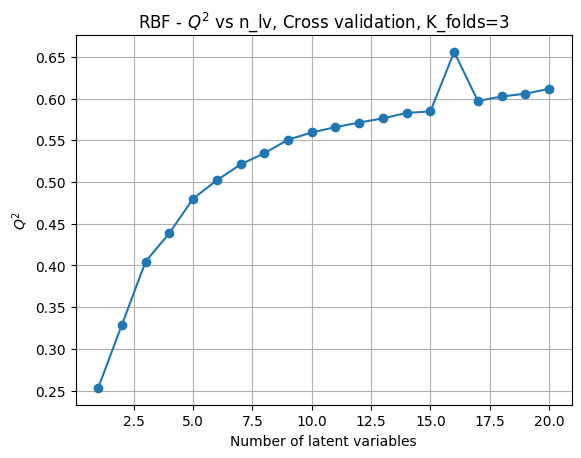

Best CV n_lv=16, gamma=0.000476495, Q^2=0.6560
Evaluate n. 0, gamma=0.8200094967106035, n_lv=1
Evaluate n. 1, gamma=0.9854341197457558, n_lv=2
Evaluate n. 2, gamma=0.6822042878684775, n_lv=3
Evaluate n. 3, gamma=0.46096514758399415, n_lv=4
Evaluate n. 4, gamma=0.31056955346441995, n_lv=5
Evaluate n. 5, gamma=0.27011156782547757, n_lv=6
Evaluate n. 6, gamma=0.38470415107069045, n_lv=7
Evaluate n. 7, gamma=0.3743854373804567, n_lv=8
Evaluate n. 8, gamma=0.32384608045898183, n_lv=9
Evaluate n. 9, gamma=0.2574367399774277, n_lv=10
Evaluate n. 10, gamma=0.2619373980634943, n_lv=11
Evaluate n. 11, gamma=0.20082927559558028, n_lv=12
Evaluate n. 12, gamma=0.21885110095526655, n_lv=13
Evaluate n. 13, gamma=0.1841573820034479, n_lv=14
Evaluate n. 14, gamma=0.33738076459571553, n_lv=15
Evaluate n. 15, gamma=0.0004764947003559575, n_lv=16
Evaluate n. 16, gamma=0.2149277469445256, n_lv=17
Evaluate n. 17, gamma=0.16266171405456376, n_lv=18
Evaluate n. 18, gamma=0.15293388740470326, n_lv=19
Evaluate 

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 2, gamma: 14.359365946052264, q2: 6.107166533597663e-08
n_lv: 3, gamma: 14.361019748199027, q2: 6.109152267397278e-08
n_lv: 4, gamma: 14.36126874461668, q2: 6.10884105523013e-08
n_lv: 1, gamma: 14.27205399873041, q2: 6.80250558660056e-08
n_lv: 5, gamma: 14.36126522304779, q2: 6.10884917096044e-08


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  5.2min


n_lv: 6, gamma: 14.3612667698562, q2: 6.108845979069244e-08
n_lv: 7, gamma: 14.361270926533749, q2: 6.108846078989316e-08
n_lv: 8, gamma: 14.361275200609787, q2: 6.108846067887086e-08
n_lv: 9, gamma: 14.361277453908881, q2: 6.108846073438201e-08
n_lv: 10, gamma: 14.361273051195045, q2: 6.108846073438201e-08


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  8.2min


n_lv: 11, gamma: 14.361279850224971, q2: 6.108846078989316e-08
n_lv: 12, gamma: 14.361268899263807, q2: 6.108846073438201e-08
n_lv: 13, gamma: 14.361268899264871, q2: 6.108846073438201e-08
n_lv: 14, gamma: 14.361268899264871, q2: 6.108846073438201e-08
n_lv: 15, gamma: 14.361268899263807, q2: 6.108846073438201e-08
n_lv: 16, gamma: 14.361268899264871, q2: 6.108846073438201e-08


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 11.9min remaining:  3.0min


n_lv: 17, gamma: 14.361268899264871, q2: 6.108846073438201e-08
n_lv: 18, gamma: 14.361268899264871, q2: 6.108846073438201e-08
n_lv: 19, gamma: 14.361268899263807, q2: 6.108846073438201e-08
n_lv: 20, gamma: 14.361268899264871, q2: 6.108846073438201e-08


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 15.3min finished


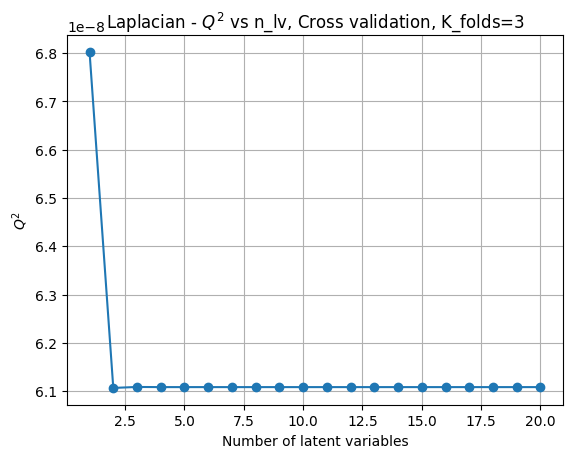

Best CV n_lv=1, gamma=14.2721, Q^2=0.0000
Skipping eval 0 -> cv Q^2 is less than 0.2
Skipping eval 1 -> cv Q^2 is less than 0.2
Skipping eval 2 -> cv Q^2 is less than 0.2
Skipping eval 3 -> cv Q^2 is less than 0.2
Skipping eval 4 -> cv Q^2 is less than 0.2
Skipping eval 5 -> cv Q^2 is less than 0.2
Skipping eval 6 -> cv Q^2 is less than 0.2
Skipping eval 7 -> cv Q^2 is less than 0.2
Skipping eval 8 -> cv Q^2 is less than 0.2
Skipping eval 9 -> cv Q^2 is less than 0.2
Skipping eval 10 -> cv Q^2 is less than 0.2
Skipping eval 11 -> cv Q^2 is less than 0.2
Skipping eval 12 -> cv Q^2 is less than 0.2
Skipping eval 13 -> cv Q^2 is less than 0.2
Skipping eval 14 -> cv Q^2 is less than 0.2
Skipping eval 15 -> cv Q^2 is less than 0.2
Skipping eval 16 -> cv Q^2 is less than 0.2
Skipping eval 17 -> cv Q^2 is less than 0.2
Skipping eval 18 -> cv Q^2 is less than 0.2
Skipping eval 19 -> cv Q^2 is less than 0.2


KeyError: 'q2_train_cv'

In [ ]:
max_lv = 20
subset_size = 20000

train_data1, validation_data1, dropped_cols1 = train_from_file("./NASA-Turbofan-data/data/train_FD001.txt")
test_data1 = test_from_file("./NASA-Turbofan-data/data/test_FD001.txt", "./NASA-Turbofan-data/data/RUL_FD001.txt", dropped_cols=dropped_cols1)
train_data1, validation_data1, test_data1, mu_train1, sd_train1 = normalize_data(train_data1, validation_data1, test_data1)
process_dataset(train_data1, validation_data1, test_data1, "FD001", max_lv, train_subset_size=None, n_jobs=4)

train_data2, validation_data2, dropped_cols2 = train_from_file("./NASA-Turbofan-data/data/train_FD002.txt")
test_data2 = test_from_file("./NASA-Turbofan-data/data/test_FD002.txt", "./NASA-Turbofan-data/data/RUL_FD002.txt", dropped_cols=dropped_cols2)
train_data2 = subsample_time_series(
        train_data2, target_rows=subset_size,
        unit_col="unit number", order_col=None,
        keep_tail=50, min_per_unit=40, seed=42
    )

train_data2, validation_data2, test_data2, mu_train2, sd_train2 = normalize_data(train_data2, validation_data2, test_data2)
process_dataset(train_data2, validation_data2, test_data2, "FD002", max_lv, train_subset_size=None, n_jobs=4)

train_data3, validation_data3, dropped_cols3 = train_from_file("./NASA-Turbofan-data/data/train_FD003.txt")
test_data3 = test_from_file("./NASA-Turbofan-data/data/test_FD003.txt", "./NASA-Turbofan-data/data/RUL_FD003.txt", dropped_cols=dropped_cols3)
train_data3, validation_data3, test_data3, mu_train3, sd_train3 = normalize_data(train_data3, validation_data3, test_data3)
process_dataset(train_data3, validation_data3, test_data3, "FD003",max_lv, train_subset_size=None, n_jobs=4)

train_data4, validation_data4, dropped_cols4 = train_from_file("./NASA-Turbofan-data/data/train_FD004.txt")
test_data4 = test_from_file("./NASA-Turbofan-data/data/test_FD004.txt", "./NASA-Turbofan-data/data/RUL_FD004.txt", dropped_cols=dropped_cols4)
train_data4 = subsample_time_series(
        train_data4, target_rows=subset_size,
        unit_col="unit number", order_col=None,
        keep_tail=50, min_per_unit=40, seed=42
    )
train_data4, validation_data4, test_data4, mu_train4, sd_train4 = normalize_data(train_data4, validation_data4, test_data4)

process_dataset(train_data4, validation_data4, test_data4, "FD004",max_lv, train_subset_size=None, n_jobs=4)